## Setup and Data Export

In [3]:
!pip install fastf1

Defaulting to user installation because normal site-packages is not writeable


In [4]:
  import fastf1
  import os
  os.makedirs('cache', exist_ok=True)
  fastf1.Cache.enable_cache('cache')
  session = fastf1.get_session(2023, 'Bahrain', 'R')
  session.load()
  print(session.laps[['Driver','LapTime','Compound','TyreLife']].head(10))

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


  Driver                LapTime Compound  TyreLife
0    VER 0 days 00:01:39.019000     SOFT       4.0
1    VER 0 days 00:01:37.974000     SOFT       5.0
2    VER 0 days 00:01:38.006000     SOFT       6.0
3    VER 0 days 00:01:37.976000     SOFT       7.0
4    VER 0 days 00:01:38.035000     SOFT       8.0
5    VER 0 days 00:01:37.986000     SOFT       9.0
6    VER 0 days 00:01:38.021000     SOFT      10.0
7    VER 0 days 00:01:38.154000     SOFT      11.0
8    VER 0 days 00:01:38.278000     SOFT      12.0
9    VER 0 days 00:01:38.369000     SOFT      13.0


In [5]:
  import fastf1
  import pandas as pd
  import os
  os.makedirs('cache', exist_ok=True)
  fastf1.Cache.enable_cache('cache')

  races = [
      (2023, 'Bahrain', 'R'),
      (2023, 'Monaco', 'R'),
      (2023, 'Monza', 'R'),
  ]

  all_laps = []
  for year, gp, session_type in races:
      session = fastf1.get_session(year, gp, session_type)
      session.load()
      laps = session.laps[['Driver','Team','LapNumber','LapTime',
                            'Compound','TyreLife','Stint','IsPersonalBest']].copy()
      laps['Race'] = gp
      laps['Year'] = year
      all_laps.append(laps)

  df = pd.concat(all_laps)
  df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds()
  df.to_csv(r'C:\Users\shrik\Desktop\f1_laps.csv', index=False)
  print(f"Exported {len(df)} laps.")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Monaco Grand Prix - Rac

Exported 3528 laps.


## Data Validation
Quick Checks on exported data before analysis

In [6]:
df.shape

(3528, 11)

In [7]:
df.info()

<class 'fastf1.core.Laps'>
Index: 3528 entries, 0 to 956
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   Driver          3528 non-null   object         
 1   Team            3528 non-null   object         
 2   LapNumber       3528 non-null   float64        
 3   LapTime         3515 non-null   timedelta64[ns]
 4   Compound        3528 non-null   object         
 5   TyreLife        3528 non-null   float64        
 6   Stint           3528 non-null   float64        
 7   IsPersonalBest  3517 non-null   object         
 8   Race            3528 non-null   object         
 9   Year            3528 non-null   int64          
 10  LapTimeSeconds  3515 non-null   float64        
dtypes: float64(4), int64(1), object(5), timedelta64[ns](1)
memory usage: 330.8+ KB


In [8]:
df.describe()

,LapNumber,LapTime,TyreLife,Stint,Year,LapTimeSeconds
count,3528.000000,3515,3528.000000,3528.00000,3528.0,3515.000000
mean,31.897392,0 days 00:01:30.404250355,15.064059,1.95068,2023.0,90.404250
std,19.530634,0 days 00:00:10.285557441,11.294339,0.94885,0.0,10.285557
min,1.000000,0 days 00:01:15.650000,1.000000,1.00000,2023.0,75.650000
25%,15.000000,0 days 00:01:20.282500,7.000000,1.00000,2023.0,80.282500
50%,31.000000,0 days 00:01:27.481000,12.500000,2.00000,2023.0,87.481000
75%,46.000000,0 days 00:01:38.260000,20.000000,3.00000,2023.0,98.260000
max,78.000000,0 days 00:02:26.648000,56.000000,7.00000,2023.0,146.648000


In [9]:
df['Compound'].value_counts()

Compound
HARD            1760
MEDIUM           837
SOFT             487
INTERMEDIATE     399
WET               45
Name: count, dtype: int64

In [10]:
df['Driver'].value_counts()

Driver
VER    186
GAS    186
ALO    186
RUS    186
SAI    186
HAM    186
BOT    185
ALB    185
ZHO    184
PER    184
HUL    183
NOR    183
SAR    183
MAG    178
LEC    169
STR    162
OCO    158
PIA    141
DEV    133
TSU    133
LAW     51
Name: count, dtype: int64

# Tire Degradation Analysis

## Degradation by Compound

   Compound  TyreLife  LapTimeSeconds
0      HARD       1.0      109.787077
1      HARD       2.0       91.766537
2      HARD       3.0       92.370463
3      HARD       4.0       94.901968
4      HARD       5.0       91.763108
5      HARD       6.0       91.308701
6      HARD       7.0       91.338621
7      HARD       8.0       90.802231
8      HARD       9.0       90.394708
9      HARD      10.0       91.491391
10     HARD      11.0       91.263839
11     HARD      12.0       90.532371
12     HARD      13.0       90.474935
13     HARD      14.0       91.381871
14     HARD      15.0       90.124034
15     HARD      16.0       89.241037
16     HARD      17.0       88.295640
17     HARD      18.0       88.862720
18     HARD      19.0       87.180156
19     HARD      20.0       87.724222


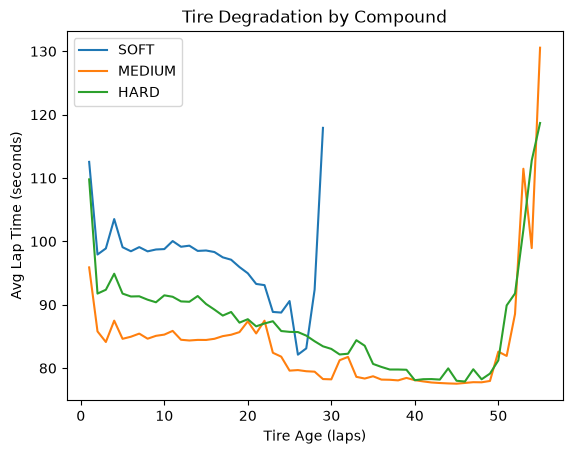

In [11]:
  import pandas as pd
  df = pd.read_csv('f1_laps.csv')

  # Filter
  df_clean = df[df['LapTimeSeconds'] > 60]

  # Groupby — the most important operation
  deg = df_clean.groupby(['Compound','TyreLife'])['LapTimeSeconds'].mean().reset_index()
  print(deg.head(20))

  # Basic chart
  import matplotlib.pyplot as plt
  for compound in ['SOFT','MEDIUM','HARD']:
      subset = deg[deg['Compound'] == compound]
      plt.plot(subset['TyreLife'], subset['LapTimeSeconds'], label=compound)
  plt.legend()
  plt.xlabel('Tire Age (laps)')
  plt.ylabel('Avg Lap Time (seconds)')
  plt.title('Tire Degradation by Compound')
  plt.show()

 Here we have the tire degradation chart for the three compounds - Soft, Medium and Hards.


 As visible here the Medium tires experience the most drastic jump from an average of 95 sec/lap to 130 sec/lap.


 The Soft tires see the least change going from around 112 sec/lap to 118 sec/lap.

 The Hard tires go from 110 sec/lap to 118 sec/lap.

The data is across 3 race sessions. 

## Finding the pit window

In [13]:
  # Find the lap where each compound "falls off a cliff"
  # (where lap time increases sharply vs. previous lap)
  deg['delta'] = deg.groupby('Compound')['LapTimeSeconds'].diff()
  cliff = deg[deg['delta'] > 1.0]  # adjust threshold
  print("Cliff laps per compound:")
  print(cliff.groupby('Compound')['TyreLife'].min())

Cliff laps per compound:
Compound
HARD            4.0
INTERMEDIATE    3.0
MEDIUM          4.0
SOFT            4.0
WET             2.0
Name: TyreLife, dtype: float64


The above data is not at all accurate. Anyone who watches F1 knows, the tires dont fall off just after 3 or 4 laps. 

We need to filter this data because of couple reasons. The data currently shows us false positives as well. 

Even by increasing the delta time there isnt any noticeable differnce in the cliff lap

This means that if there is any chaos in the first few laps or if a driver goes slow due to a brief yellow flag, lock up it will trigger these false cliffs.


Therefore we need to make the following changes to find out the correct cliff lap.

## Finding the pit window (Corrected)

In [15]:
df_stint = deg[deg['TyreLife']>10].copy()
df_stint['SmoothedLapTime'] = df_stint.groupby('Compound')['LapTimeSeconds'].transform(lambda x: x.rolling(window = 3, min_periods = 1).mean())
df_stint['SmoothedDelta'] = df_stint.groupby('Compound')['SmoothedLapTime'].diff()
cliff = df_stint[df_stint['SmoothedDelta'] > 1.5]
print("True Cliff Laps per Compound: ")
print(cliff.groupby('Compound')['TyreLife'].min())

True Cliff Laps per Compound: 
Compound
HARD      51.0
MEDIUM    50.0
SOFT      29.0
WET       13.0
Name: TyreLife, dtype: float64


## Driver Consistency Ranking

In [16]:
  driver_deg = df_clean.groupby(['Driver','Compound'])['LapTimeSeconds'].agg(['mean','std']).reset_index()
  driver_deg.columns = ['Driver','Compound','avg_laptime','consistency_std']
  driver_deg['consistency_cv'] = driver_deg['consistency_std'] / driver_deg['avg_laptime']
  driver_deg = driver_deg[driver_deg['Compound'].notna()]
  print(driver_deg.sort_values('consistency_cv').head(10))

   Driver Compound  avg_laptime  consistency_std  consistency_cv
34    LEC     SOFT    99.205692         0.976607        0.009844
7     ALO     SOFT   100.441714         1.207456        0.012021
63    SAI     SOFT   100.052692         1.248201        0.012475
23    HAM     SOFT   100.307250         1.299077        0.012951
71    STR     SOFT   100.583933         1.441079        0.014327
11    BOT     SOFT   100.890818         1.474707        0.014617
58    RUS   MEDIUM    87.231474         1.341502        0.015379
59    RUS     SOFT   100.604154         1.563022        0.015536
46    OCO     SOFT   101.172833         1.836941        0.018156
70    STR   MEDIUM    88.586250         2.292535        0.025879


The above chart utilizes Standard Deviation to measure spread/variance across the average. Looking at the list we can conclude Leclerc was the most consistent driver since he was able to manage the tires the best.
If we dont apply std dev, then comparisons across compounds wont be accurate. 

### Until this point, we have pulled the data from FastF1, validated and performed analysis on it. We have the tire deg analysis which tells us the cliff laps for each compound, the correct pit window and the consistency of drivers. Now further, we will be pulling data across multiple season to improve the analysis.